# MNIST Classification (V1: Baseline ANN)

This notebook implements a simple Artificial Neural Network (ANN) on the MNIST dataset.

The goal is to establish a baseline model before applying any regularization or architectural improvements.

In [1]:
## IMPORTS :

import numpy as np
import matplotlib.pyplot as plt 
import warnings
warnings.filterwarnings('ignore')  

import tensorflow
from tensorflow import keras
from keras import Sequential
from keras.layers import Dense
from tensorflow.keras.datasets import mnist 


### Load Dataset : 
The MNIST dataset contains grayscale images of handwritten digits (0–9).

In [2]:
(X_train, y_train), (X_test, y_test) = mnist.load_data()

### Data Preprocessing : 
- Normalize pixel values to range [0, 1]
- Flatten images from 28×28 to 784 features

In [3]:
X_train = X_train / 255.0
X_test = X_test / 255.0

X_train = X_train.reshape(-1, 28*28)
X_test = X_test.reshape(-1, 28*28)

### Model Architecture : 
A simple feedforward neural network:
- One hidden layer with 128 neurons
- ReLU activation
- Output layer with Softmax

In [4]:
model = Sequential()

model.add(Dense(128, activation='relu', input_shape=(784,)))
model.add(Dense(10, activation='softmax'))

In [5]:
## MODEL COMPILE : 

model.compile(optimizer='adam',
              loss='sparse_categorical_crossentropy',
              metrics=['accuracy'])

### Model Training : 
Train the model for a fixed number of epochs.

In [6]:
history = model.fit(X_train, y_train,
    validation_data=(X_test, y_test),
    epochs=10)

Epoch 1/10
1875/1875 ━━━━━━━━━━━━━━━━━━━━ 6s 3ms/step - accuracy: 0.9260 - loss: 0.2587 - val_accuracy: 0.9610 - val_loss: 0.1305
Epoch 2/10
1875/1875 ━━━━━━━━━━━━━━━━━━━━ 5s 3ms/step - accuracy: 0.9657 - loss: 0.1151 - val_accuracy: 0.9606 - val_loss: 0.1204
Epoch 3/10
1875/1875 ━━━━━━━━━━━━━━━━━━━━ 5s 3ms/step - accuracy: 0.9767 - loss: 0.0784 - val_accuracy: 0.9760 - val_loss: 0.0803
Epoch 4/10
1875/1875 ━━━━━━━━━━━━━━━━━━━━ 5s 2ms/step - accuracy: 0.9815 - loss: 0.0601 - val_accuracy: 0.9782 - val_loss: 0.0732
Epoch 5/10
1875/1875 ━━━━━━━━━━━━━━━━━━━━ 5s 3ms/step - accuracy: 0.9856 - loss: 0.0462 - val_accuracy: 0.9782 - val_loss: 0.0781
Epoch 6/10
1875/1875 ━━━━━━━━━━━━━━━━━━━━ 5s 3ms/step - accuracy: 0.9878 - loss: 0.0377 - val_accuracy: 0.9790 - val_loss: 0.0714
Epoch 7/10
1875/1875 ━━━━━━━━━━━━━━━━━━━━ 5s 3ms/step - accuracy: 0.9920 - loss: 0.0283 - val_accuracy: 0.9767 - val_loss: 0.0784
Epoch 8/10
1875/1875 ━━━━━━━━━━━━━━━━━━━━ 5s 3ms/step - accuracy: 0.9926 - loss: 0.0247 - 

### Accuracy Plot : 
Visualize training vs validation accuracy.

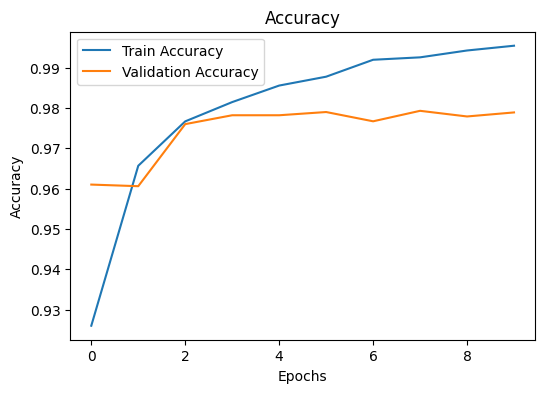

In [9]:
plt.figure(figsize=(6,4))

plt.plot(history.history['accuracy'])
plt.plot(history.history['val_accuracy'])
plt.legend(['Train Accuracy', 'Validation Accuracy'])
plt.title('Accuracy')
plt.xlabel('Epochs')
plt.ylabel('Accuracy')
plt.show()


### Loss Plot : 
Helps identify overfitting or underfitting.

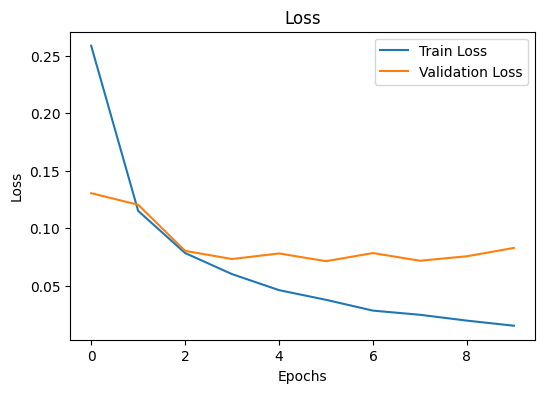

In [10]:
plt.figure(figsize=(6,4)) 

plt.plot(history.history['loss'])
plt.plot(history.history['val_loss'])
plt.legend(['Train Loss', 'Validation Loss'])
plt.title('Loss')
plt.xlabel('Epochs')
plt.ylabel('Loss')
plt.show() 


### Model Evaluation : 
Evaluate the model on unseen test data.

In [11]:
model.evaluate(X_test, y_test)

313/313 ━━━━━━━━━━━━━━━━━━━━ 1s 2ms/step - accuracy: 0.9789 - loss: 0.0829 


[0.08286766707897186, 0.9789000153541565]

### Sample Prediction : 
Visual check of model prediction on a test image.

313/313 ━━━━━━━━━━━━━━━━━━━━ 0s 1ms/step 


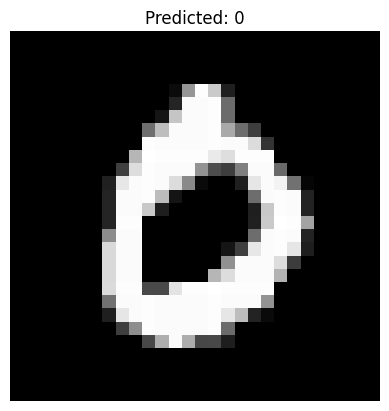

In [13]:
## Prediction + Image :

predictions = model.predict(X_test)

index = 3
plt.imshow(X_test[index].reshape(28, 28), cmap='gray')
plt.title(f"Predicted: {np.argmax(predictions[index])}")
plt.axis('off')
plt.show()

## Conclusion : 

- The baseline ANN achieves strong performance (~97–98% accuracy)
- Some gap between training and validation suggests mild overfitting
- This serves as a reference point for further improvements (e.g., Dropout, EarlyStopping)

This baseline helps evaluate the impact of future model enhancements.